# Getaround - EDA

## Objectifs

- Comprendre les retards et leurs impacts

In [1]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import root_mean_squared_error, r2_score

import warnings

warnings.filterwarnings(
    "ignore", category=DeprecationWarning
)  # to avoid deprecation warnings

In [13]:
# Lecture des fichiers
print("Loading dataset...")
dataset = pd.read_excel("D:/Profils/NLefort/Desktop/JEDHA/PROJETS/08.Déploiement/data/get_around_delay_analysis.xlsx")
print("...Done.")

Loading dataset...
...Done.


In [ ]:
## Analyse descriptive
# INFORMATIONS GENERALES
print("\n INFORMATIONS GENERALES")
print("-"*40)

print("Nombre de lignes (=rental_id) : {}".format(dataset.shape[0]))
print("Nombre de colonnes : {}".format(dataset.shape[1]))
print("Nombre de véhicules : {}".format(dataset['car_id'].nunique()))

print("Aperçu du dataset : ")
display(dataset.head())

print("Types de données/colonnes : ")
display(dataset.dtypes)



 INFORMATIONS GENERALES
----------------------------------------
Nombre de lignes (=rental_id) : 21310
Nombre de colonnes : 7
Nombre de véhicules : 8143
Aperçu du dataset : 


,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.0,NaN,NaN
2,508131,359049,connect,ended,70.0,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN


Types de données/colonnes : 


rental_id                                       int64
car_id                                          int64
checkin_type                                   object
state                                          object
delay_at_checkout_in_minutes                  float64
previous_ended_rental_id                      float64
time_delta_with_previous_rental_in_minutes    float64
dtype: object

In [ ]:
# VALEURS MANQUANTES
print("\n VALEURS MANQUANTES")
print("-"*40)

print("Nombre de valeurs manquantes par colonne :")
missing_values = dataset.isnull().sum()
missing_values_percentage = ((missing_values / dataset.shape[0]) * 100).round(2)
missing_df = pd.DataFrame({
    "Valeurs manquantes": missing_values,
    "Pourcentage": missing_values_percentage
})
display(missing_df[missing_df["Valeurs manquantes"] > 0])

# CONVERSION VALEURS NUMERIQUES
dataset['delay_at_checkout_in_minutes'] = pd.to_numeric(dataset['delay_at_checkout_in_minutes'], errors='coerce')
dataset['time_delta_with_previous_rental_in_minutes'] = pd.to_numeric(dataset['time_delta_with_previous_rental_in_minutes'], errors='coerce')




 VALEURS MANQUANTES
----------------------------------------
Nombre de valeurs manquantes par colonne :


,Valeurs manquantes,Pourcentage
delay_at_checkout_in_minutes,4964,23.29
previous_ended_rental_id,19469,91.36
time_delta_with_previous_rental_in_minutes,19469,91.36


In [24]:
# STATISTIQUES DESCRIPTIVES
# Statistiques descriptives globales
print("Statistiques descriptives globales :")
display(dataset.describe(include="all").round(2))

Statistiques descriptives globales :


,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
count,21310.00,21310.00,21310,21310,16346.00,1841.00,1841.00
unique,NaN,NaN,2,2,NaN,NaN,NaN
top,NaN,NaN,mobile,ended,NaN,NaN,NaN
freq,NaN,NaN,17003,18045,NaN,NaN,NaN
mean,549712.88,350030.60,NaN,NaN,59.70,550127.41,279.29
std,13863.45,58206.25,NaN,NaN,1002.56,13184.02,254.59
min,504806.00,159250.00,NaN,NaN,-22433.00,505628.00,0.00
25%,540613.25,317639.00,NaN,NaN,-36.00,540896.00,60.00
50%,550350.00,368717.00,NaN,NaN,9.00,550567.00,180.00
75%,560468.50,394928.00,NaN,NaN,67.00,560823.00,540.00


C:\Users\NLefort\AppData\Local\Temp\ipykernel_12064\1759864039.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='state', data=dataset, ax=axes[1], palette='pastel', order=dataset['state'].value_counts().index)


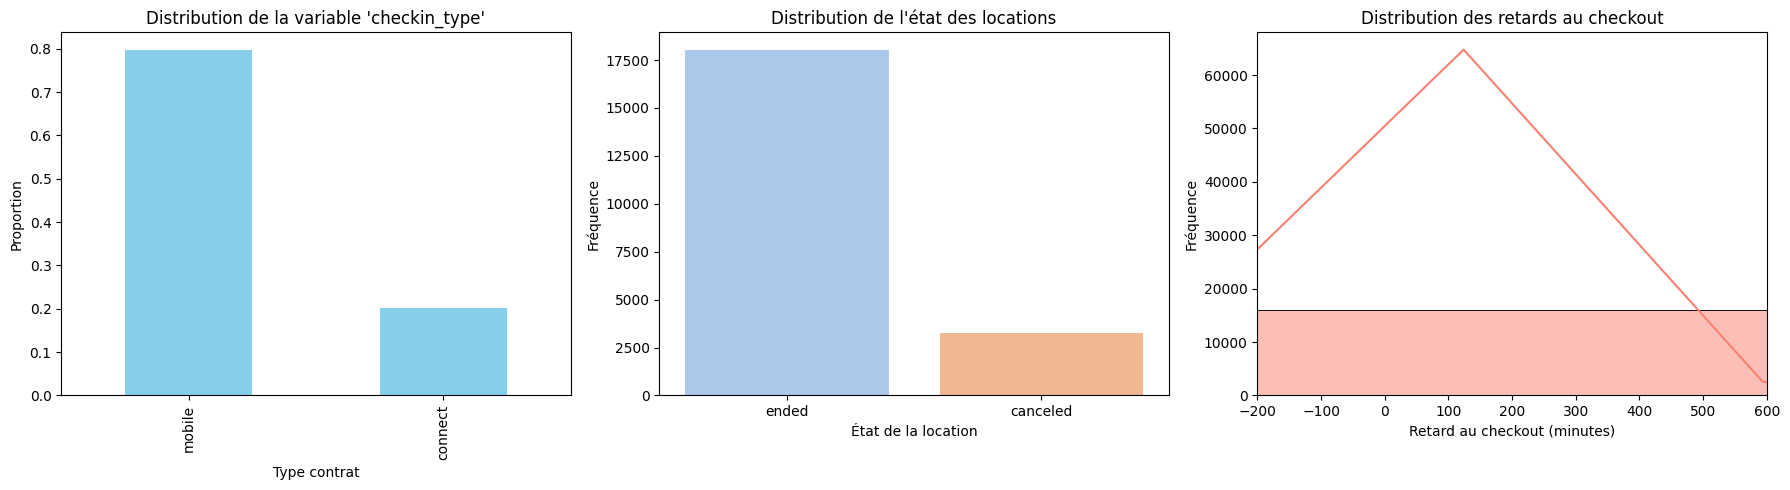

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Variable "checkin_type"
dataset['checkin_type'].value_counts(normalize=True).plot.bar(ax=axes[0], color='skyblue')
axes[0].set_title("Distribution de la variable 'checkin_type'")
axes[0].set_ylabel("Proportion")
axes[0].set_xlabel("Type contrat")

# Variable "state"
sns.countplot(x='state', data=dataset, ax=axes[1], palette='pastel', order=dataset['state'].value_counts().index)
axes[1].set_title("Distribution de l'état des locations", fontsize=12)
axes[1].set_xlabel("État de la location")
axes[1].set_ylabel("Fréquence")

# Variable "total_pages_visited"
sns.histplot(dataset['delay_at_checkout_in_minutes'].dropna(), bins=40, kde=True, ax=axes[2], color='salmon')
axes[2].set_title("Distribution des retards au checkout", fontsize=12)
axes[2].set_xlabel("Retard au checkout (minutes)")
axes[2].set_ylabel("Fréquence")
axes[2].set_xlim(-200, 600)  # optionnel pour couper les valeurs extrêmes

plt.tight_layout()
plt.show()

Taux global de retards : 44.13%


C:\Users\NLefort\AppData\Local\Temp\ipykernel_12064\3942068826.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='checkin_type', y='retard_rate', data=retard_by_type, palette='viridis')


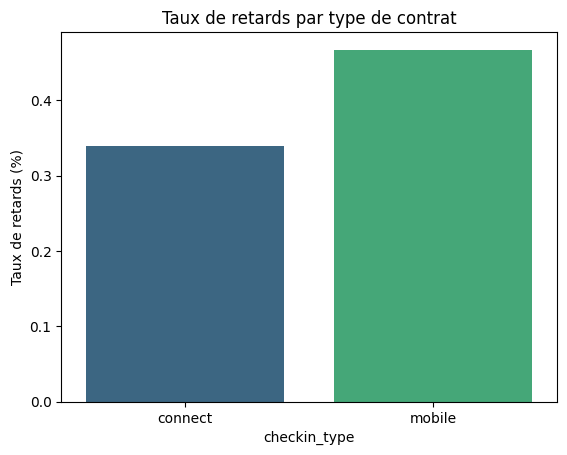

In [ ]:
# Taux de retard global
taux_retard = (dataset['delay_at_checkout_in_minutes'] > 0).mean()
print(f"Taux global de retards : {taux_retard:.2%}")